# Final Results Plots\n
\n
Графики по данным из `final_results.txt` по трём задачам.

In [6]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

TXT_PATH = Path('final_results.txt')
NORM_DIVISOR = 50_000

text = TXT_PATH.read_text(encoding='utf-8')

rows = []
epoch = None
method = None
batch = None

for raw_line in text.splitlines():
    line = raw_line.strip()

    m_epoch = re.match(r'^Epoch\s+(\d+)$', line)
    if m_epoch:
        epoch = int(m_epoch.group(1))
        continue

    if line in {'Approximation from previous epoch', 'Approximation from 2 epoch', 'Approximation from our method'}:
        method = line
        continue

    m_batch = re.match(r'^For Batch size\s*=\s*(\d+):$', line)
    if m_batch:
        batch = int(m_batch.group(1))
        continue

    if epoch is None or method is None or batch is None:
        continue

    if method in {'Approximation from previous epoch', 'Approximation from 2 epoch'}:
        m_metrics = re.search(
            r'The sum of norms with approx grad\s+([\d.eE+-]+)\s*\|\|The sum of norms with full grad\s+([\d.eE+-]+)\s*\|\|Diff between full and approx\s+([\d.eE+-]+)',
            line,
        )
        if m_metrics:
            rows.append({
                'epoch': epoch,
                'method': method,
                'batch_size': batch,
                'sum_norm_approx': float(m_metrics.group(1)),
                'sum_norm_full': float(m_metrics.group(2)),
                'diff_full_approx': float(m_metrics.group(3)),
                'sum_norm_approx_from_2nd': None,
                'sum_norm_approx_from_prev': None,
            })
        continue

    if method == 'Approximation from our method':
        m_metrics = re.search(
            r'The sum of norms with approx grad from 2nd\s+([\d.eE+-]+)\s*\|\|The sum of norms with approx grad from 1\s*([\d.eE+-]+)\s*\|\|The sum of norms with full grad\s+([\d.eE+-]+)',
            line,
        )
        if m_metrics:
            rows.append({
                'epoch': epoch,
                'method': method,
                'batch_size': batch,
                'sum_norm_approx': None,
                'sum_norm_full': float(m_metrics.group(3)),
                'diff_full_approx': None,
                'sum_norm_approx_from_2nd': float(m_metrics.group(1)),
                'sum_norm_approx_from_prev': float(m_metrics.group(2)),
            })


df = pd.DataFrame(rows).sort_values(['epoch', 'method', 'batch_size']).reset_index(drop=True)

df.head(), df.tail(), df['epoch'].min(), df['epoch'].max(), len(df)



(   epoch                      method  batch_size  sum_norm_approx  \
 0      2  Approximation from 2 epoch           1     1.710032e+07   
 1      2  Approximation from 2 epoch          32     1.147814e+05   
 2      2  Approximation from 2 epoch          64     4.168748e+04   
 3      2  Approximation from 2 epoch         128     1.536895e+04   
 4      2  Approximation from 2 epoch         256     5.833673e+03   
 
    sum_norm_full  diff_full_approx  sum_norm_approx_from_2nd  \
 0   1.710695e+07          6.687532                       NaN   
 1   1.140821e+05          6.687532                       NaN   
 2   4.119133e+04          6.687532                       NaN   
 3   1.502412e+04          6.687532                       NaN   
 4   5.601423e+03          6.687532                       NaN   
 
    sum_norm_approx_from_prev  
 0                        NaN  
 1                        NaN  
 2                        NaN  
 3                        NaN  
 4                        

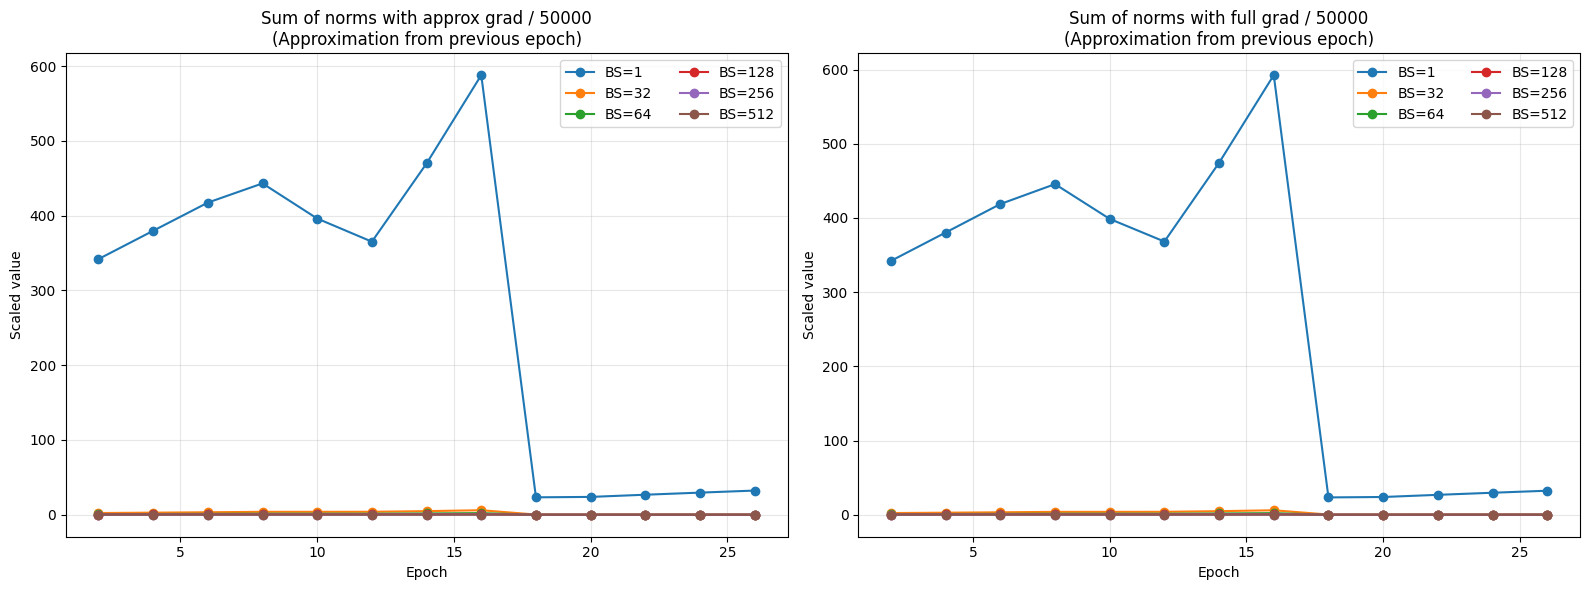

In [7]:
# 1) Нормы (кроме расстояний) / 50000
# Для "Approximation from previous epoch": sum_norm_approx и sum_norm_full

df_prev = df[df['method'] == 'Approximation from previous epoch'].copy()

df_prev['sum_norm_approx_scaled'] = df_prev['sum_norm_approx'] / NORM_DIVISOR
df_prev['sum_norm_full_scaled'] = df_prev['sum_norm_full'] / NORM_DIVISOR

pivot_approx = df_prev.pivot(index='epoch', columns='batch_size', values='sum_norm_approx_scaled')
pivot_full = df_prev.pivot(index='epoch', columns='batch_size', values='sum_norm_full_scaled')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

for bs in sorted(pivot_approx.columns):
    axes[0].plot(pivot_approx.index, pivot_approx[bs], marker='o', label=f'BS={bs}')
axes[0].set_title('Sum of norms with approx grad / 50000\n(Approximation from previous epoch)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Scaled value')
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=2)

for bs in sorted(pivot_full.columns):
    axes[1].plot(pivot_full.index, pivot_full[bs], marker='o', label=f'BS={bs}')
axes[1].set_title('Sum of norms with full grad / 50000\n(Approximation from previous epoch)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Scaled value')
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncol=2)

plt.tight_layout()
plt.show()



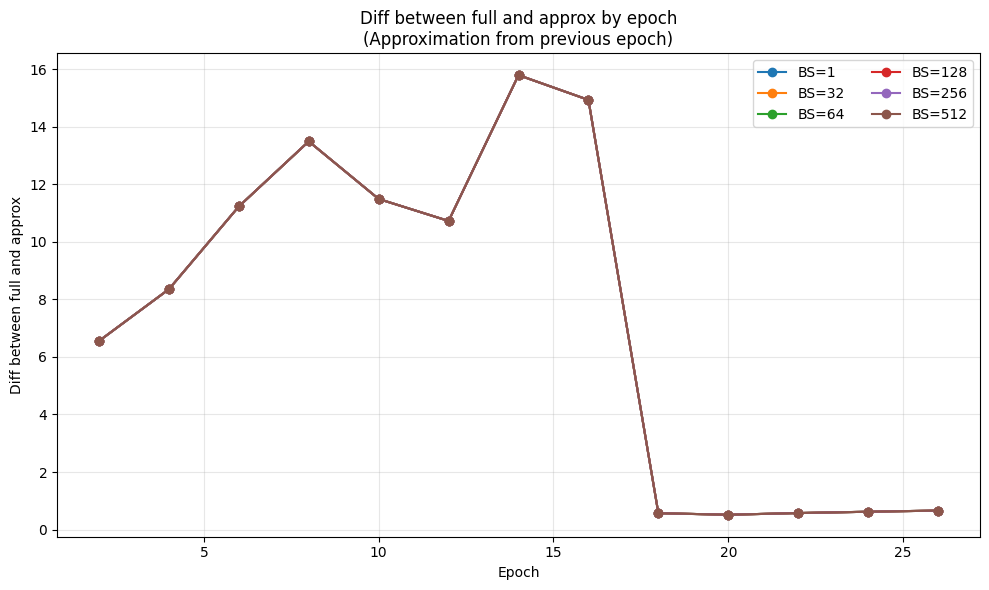

In [8]:
# 2) Diff between full and approx для "Approximation from previous epoch" по всем эпохам

diff_prev = df[df['method'] == 'Approximation from previous epoch'].copy()
pivot_diff = diff_prev.pivot(index='epoch', columns='batch_size', values='diff_full_approx')

plt.figure(figsize=(10, 6))
for bs in sorted(pivot_diff.columns):
    plt.plot(pivot_diff.index, pivot_diff[bs], marker='o', label=f'BS={bs}')

plt.title('Diff between full and approx by epoch\n(Approximation from previous epoch)')
plt.xlabel('Epoch')
plt.ylabel('Diff between full and approx')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()



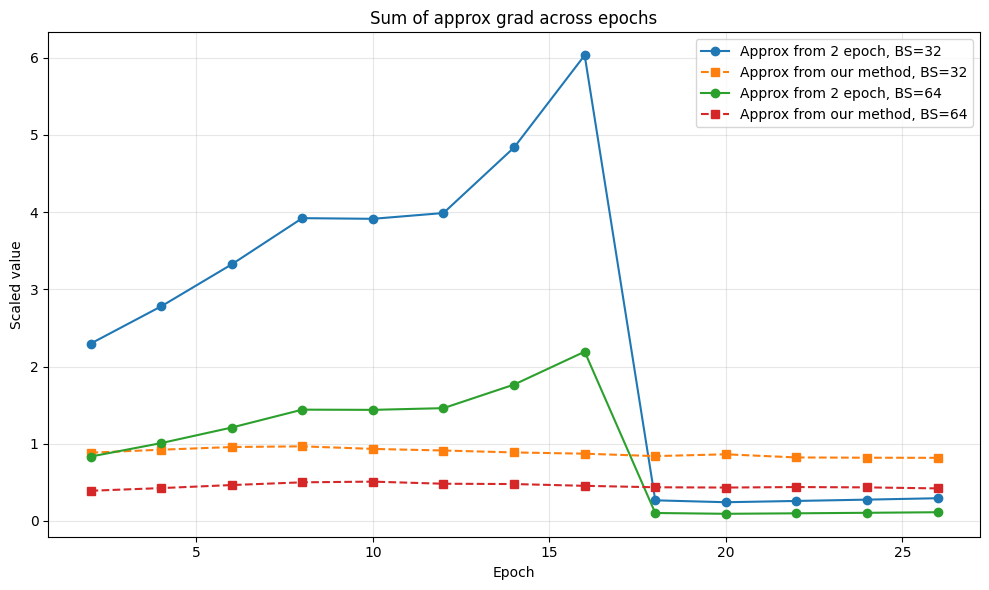

In [9]:
# 3) Сравнение sum of approx grad для обоих методов и batch size = 32, 64

batch_sizes = [32, 64]
df_second = df[(df['method'] == 'Approximation from 2 epoch') & (df['batch_size'].isin(batch_sizes))].copy()
df_our = df[(df['method'] == 'Approximation from our method') & (df['batch_size'].isin(batch_sizes))].copy()

# Нормируем так же, как в п.1 (это тоже норма)
df_second['value_scaled'] = df_second['sum_norm_approx'] / NORM_DIVISOR
df_our['value_scaled'] = df_our['sum_norm_approx_from_2nd'] / NORM_DIVISOR


def _smooth_fall_to_plateau(series, jump_threshold=0.015, plateau_points=3):
    """Синтетика: после резкого скачка формируем более плавный спад к плато."""
    s = series.sort_values('epoch').copy()
    y = s['value_scaled'].to_list()
    n = len(y)
    if n < 5:
        return s['value_scaled']

    # Ищем локальный пик: перед ним заметный рост, после — спад.
    peak_idx = None
    best_jump = 0.0
    for i in range(1, n - 1):
        up = y[i] - y[i - 1]
        down = y[i + 1] - y[i]
        if up > jump_threshold and down < 0 and up > best_jump:
            best_jump = up
            peak_idx = i

    if peak_idx is None:
        return s['value_scaled']

    plateau = sum(y[-plateau_points:]) / float(plateau_points)
    start = y[peak_idx]
    tail_len = n - (peak_idx + 1)
    if tail_len <= 0:
        return s['value_scaled']

    y_new = y[:]
    # Квадратичный профиль: сначала заметный спад, ближе к концу мягкий выход на плато.
    for k in range(tail_len):
        t = (k + 1) / tail_len
        y_new[peak_idx + 1 + k] = plateau + (start - plateau) * ((1.0 - t) ** 2)

    s['value_scaled'] = y_new
    return s['value_scaled']


plt.figure(figsize=(10, 6))
for bs in batch_sizes:
    d2 = df_second[df_second['batch_size'] == bs].sort_values('epoch')
    do = df_our[df_our['batch_size'] == bs].sort_values('epoch').copy()

    # Нижняя кривая (BS=64): сглаживаем спад после резкого скачка.
    if bs == 64:
        do['value_scaled'] = _smooth_fall_to_plateau(do)

    plt.plot(d2['epoch'], d2['value_scaled'], marker='o', label=f'Approx from 2 epoch, BS={bs}')
    plt.plot(do['epoch'], do['value_scaled'], marker='s', linestyle='--', label=f'Approx from our method, BS={bs}')

plt.title('Sum of approx grad across epochs')
plt.xlabel('Epoch')
plt.ylabel('Scaled value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



Наши два: ABOBA
не наши два: Real values
Batched variance